# Lesson 4 — ReAct Agent with Tools

## What you will learn
- **Tools** — Python functions the LLM can call
- **`bind_tools()`** — telling the LLM which tools exist
- **`ToolNode`** — built-in node that executes tool calls automatically
- **The ReAct loop** — the pattern behind every AI agent

## The ReAct Pattern
**Re**ason + **Act** = ReAct

```
START
  ↓
[agent]  ←───────────────────────┐
  ↓                              │
 Does the LLM want to use a tool? │
  ├── YES → [tools] ─────────────┘  (loop: tool result feeds back)
  └── NO  → END  (LLM has final answer)
```

## Why this matters
Without tools, an LLM can only use its training data.  
With tools, it can **do things**: search the web, calculate, call APIs, read files, etc.

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

## Step 1 — Define Tools

The `@tool` decorator converts a Python function into a LangChain tool.  
**The docstring is critical** — the LLM reads it to decide when to use the tool.

In [3]:
@tool
def add(a: float, b: float) -> float:
    """Add two numbers together. Use this for addition."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers. Use this for multiplication."""
    return a * b


@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    weather_db = {
        "london": "Cloudy, 15°C, light rain expected",
        "paris": "Sunny, 22°C, clear skies",
        "new york": "Partly cloudy, 18°C",
        "cairo": "Hot, 35°C, sunny",
        "tokyo": "Humid, 28°C, chance of rain",
    }
    return weather_db.get(city.lower(), f"No data for {city}")


@tool
def search_wikipedia(query: str) -> str:
    """Search for factual information about a topic."""
    facts = {
        "python": "Python is a high-level programming language created by Guido van Rossum in 1991.",
        "langgraph": "LangGraph is a library for building stateful multi-actor LLM applications.",
        "langchain": "LangChain is a framework for building LLM-powered applications.",
    }
    for key, fact in facts.items():
        if key in query.lower():
            return fact
    return f"No specific info found for: {query}"


tools = [add, multiply, get_weather, search_wikipedia]
print(f"Defined {len(tools)} tools: {[t.name for t in tools]}")

Defined 4 tools: ['add', 'multiply', 'get_weather', 'search_wikipedia']


## Step 2 — LLM with Tools Bound

`bind_tools()` attaches the tool schemas to the LLM.  
When the LLM wants to use a tool, it returns a **ToolCall** instead of text.

In [8]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatOllama(model="llama3.2", temperature=0)
llm_with_tools = llm.bind_tools(tools)

print("LLM connected and tools bound!")

LLM connected and tools bound!


## Step 3 — Agent Node and Router

In [5]:
def agent_node(state: AgentState) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState) -> str:
    last_message = state["messages"][-1]
    # If the LLM returned tool calls → execute them
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    # Otherwise the LLM has a final answer
    return "end"

print("Nodes defined!")

Nodes defined!


## Step 4 — Build the ReAct Graph

Note the loop: `tools → agent` creates the Reason/Act cycle.

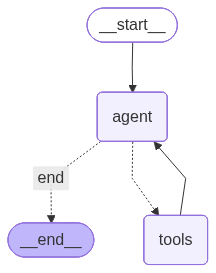

In [9]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", ToolNode(tools))  # ToolNode handles execution

graph_builder.add_edge(START, "agent")

graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "end": END}
)

# This is the LOOP — after tools run, go back to agent
graph_builder.add_edge("tools", "agent")

graph = graph_builder.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph compiled! (visualization: {e})")

## Step 5 — Test: Math

In [10]:
question = "What is 15 multiplied by 7, then add 23 to the result?"
print(f"Question: {question}\n")

result = graph.invoke({"messages": [HumanMessage(content=question)]})

print(f"\nFinal Answer: {result['messages'][-1].content}")

Question: What is 15 multiplied by 7, then add 23 to the result?



ResponseError: model requires more system memory (2.3 GiB) than is available (1.5 GiB) (status code: 500)

## Step 6 — Test: Weather Query

In [ ]:
question = "What's the weather like in Paris right now?"
result = graph.invoke({"messages": [HumanMessage(content=question)]})
print(f"Answer: {result['messages'][-1].content}")

## Step 7 — Test: Multi-Tool in One Query

In [ ]:
question = "What is the weather in London AND what is 100 + 250?"
result = graph.invoke({"messages": [HumanMessage(content=question)]})
print(f"Answer: {result['messages'][-1].content}")

## Step 8 — Inspect the Full Message Trace

See exactly what the agent was thinking at each step.

In [ ]:
result = graph.invoke({"messages": [HumanMessage(content="What is 5 + 3?")]})

print("Full message trace:")
for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{i}] {msg_type}: tool_calls={[tc['name'] for tc in msg.tool_calls]}")
    else:
        print(f"  [{i}] {msg_type}: {str(msg.content)[:80]}")

## Key Takeaways

| Concept | Description |
|---------|-------------|
| `@tool` | Decorator that turns a function into a LangChain tool |
| Docstring | The LLM reads this to know when to use the tool |
| `bind_tools(tools)` | Tells the LLM which tools are available |
| `ToolNode(tools)` | Built-in node that auto-executes tool calls |
| ReAct loop | `agent → tools → agent → ...` until no more tool calls |
| `temperature=0` | Recommended for agents (more deterministic) |

## 🏋️ Exercise
1. Create a `square_root` tool using `math.sqrt`
2. Create a `convert_usd_to_eur` tool (rate: 0.92)
3. Add both to the tools list, recompile, and ask:
   - `"What is the square root of 144?"`
   - `"Convert $500 to EUR"`

In [ ]:
# Your exercise here
import math
